# SpecklePattern
## Tracking a moving object
### Run on kernel "Python [conda env:base]"

In [1]:
import numpy as np
import matplotlib.pyplot as py
import imageio.v3 as image

In [2]:
# Gaussian Point
def GaussPoint(position,variance):
    # Gaussian Point
    # Inputs:
    # position - Input an array containing the x and y position of the object respectively
    # variance - Determines the width of the gaussian point
    #
    # Outputs:
    # gaussian - matrix containing the gaussian point
    
    maxgauss = 1

    gaussian = np.empty((dimensions,dimensions)) # Create an empty matrix the size of the speckle pattern

    for i in range(dimensions**2): # Repeat the following for each item in the speckle pattern
        ycoord = int(np.trunc(i/dimensions)) # Find the x and y coordinates of the current item
        xcoord = int(i - ycoord*dimensions)

        gaussian[xcoord,ycoord] = ((1/(2*np.pi*variance**2))*np.exp(-((xcoord-position[1])**2)/(2*variance**2)) * (1/(2*np.pi*variance**2))*np.exp(-((ycoord-position[0])**2)/(2*variance**2)))/2
        
        if gaussian[xcoord,ycoord] > maxgauss: # Ensure the gaussians maximum value is 1
            maxgauss = gaussian[xcoord,ycoord]

    gaussian = gaussian/maxgauss
    return gaussian 

In [3]:
# Form random complex speckle pattern

dimensions = 512 # dimensions refers to the length of one side of the speckle pattern (speckle pattern is a square)
padding = 400 # padding refers to double the thickness of the outer padding
halfpadding = int(np.round(padding/2))

Rspeckle = np.random.randint(low=-1, high=2, size=(dimensions-padding,dimensions-padding)) # Produce a speckle pattern made of random real
Ispeckle = np.random.randint(low=-1, high=2, size=(dimensions-padding,dimensions-padding)) # and imaginary values from 0 to 1 and combine
speckle = Ispeckle.astype(np.complex64)                      # to make a complex speckle pattern

for i in range((dimensions-padding)**2):
    ycoord = int(np.trunc(i/(dimensions-padding)))
    xcoord = int(i - ycoord*(dimensions-padding))
    speckle[xcoord,ycoord] = np.complex64(Rspeckle[xcoord,ycoord], Ispeckle[xcoord,ycoord])

In [4]:
speckle = np.pad(speckle, (halfpadding, halfpadding)) # Pad the speckle pattern with zeros

In [5]:
Fspeckle = np.fft.fft2(speckle) # Perform a Fourier transform on the speckle pattern

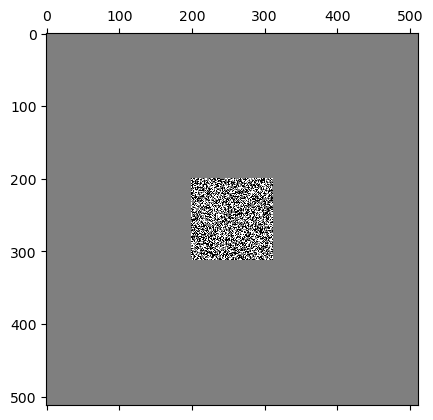

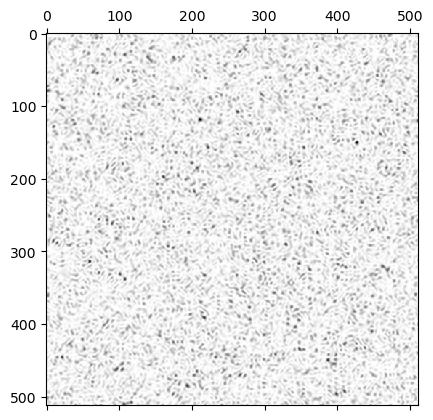

In [6]:
py.matshow((np.real(speckle)), fignum=None, cmap="binary") # Plot the speckle pattern
#py.savefig("Speckle_raw.pdf", format="pdf")
py.matshow((np.abs(Fspeckle)**2), fignum=None, cmap="binary") # Plot the Fourier transform

In [7]:
mean = Fspeckle.mean() # Find the mean value of the new speckle pattern

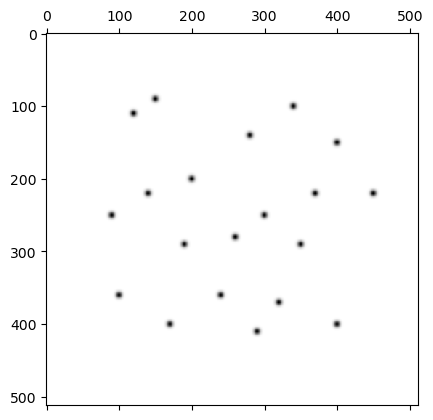

In [8]:
# Object: background (static)

backobjects = 0

# Add gaussian point as objects to image
backobjects += GaussPoint((200,200),3) 
backobjects += GaussPoint((300,250),3)
backobjects += GaussPoint((450,220),3)
backobjects += GaussPoint((290,410),3)
backobjects += GaussPoint((400,150),3)
backobjects += GaussPoint((400,400),3)
backobjects += GaussPoint((350,290),3)
backobjects += GaussPoint((240,360),3)
backobjects += GaussPoint((140,220),3)
backobjects += GaussPoint((340,100),3)

backobjects += GaussPoint((100,360),3)
backobjects += GaussPoint((90,250),3)
backobjects += GaussPoint((190,290),3)
backobjects += GaussPoint((150,90),3)
backobjects += GaussPoint((120,110),3)
backobjects += GaussPoint((280,140),3)
backobjects += GaussPoint((260,280),3)
backobjects += GaussPoint((370,220),3)
backobjects += GaussPoint((170,400),3)
backobjects += GaussPoint((320,370),3)
py.matshow(backobjects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_1dot.pdf", format="pdf")

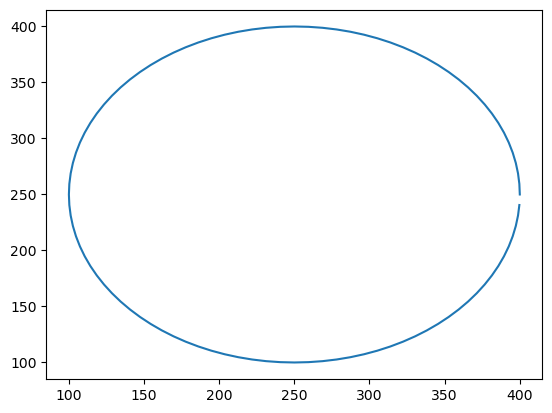

In [12]:
# Object: Moving dot path (circle)

xframe = []
yframe = []
thetaframe = []

noframes = 100
circleradius = 150
xcentre = 250
ycentre = 250

framewidth = 360/noframes
theta = 0
for i in range(noframes):
    xframe.append(circleradius*np.cos(theta*(np.pi/180)) + xcentre)
    yframe.append(circleradius*np.sin(theta*(np.pi/180)) + ycentre)
    theta += framewidth

py.plot(xframe,yframe)
#py.savefig("Circle.pdf", format="pdf")

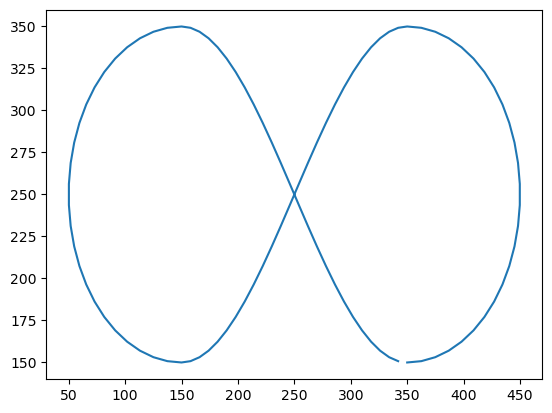

In [10]:
# Object: Moving dot path (Figure of eight)

xframe = []
yframe = []
thetaframe = []

noframes = 100
width = 400
curveradius = width/4
xcentre = 250
ycentre = 250

framewidth = 180/noframes
circletheta = 0
sinexval = xcentre + width/2 - curveradius 
sineyval = ycentre + curveradius

for i in range(int(noframes)):
    if i < int(noframes/4):
        xframe.append(curveradius*np.cos((circletheta-90)*(np.pi/180)) + xcentre + width/2 - curveradius)
        yframe.append(curveradius*np.sin((circletheta-90)*(np.pi/180)) + ycentre)
        circletheta += 4*framewidth
    elif i < int(noframes/2):
        xframe.append(sinexval)
        yframe.append(curveradius*np.sin((1/(2*curveradius))*np.pi*(sinexval - xcentre)) + ycentre)
        sinexval -= (width-2*curveradius)/(noframes/4)
    elif i < int(3*noframes/4):
        xframe.append(curveradius*np.cos((circletheta+90)*(np.pi/180)) + xcentre - width/2 + curveradius)
        yframe.append(curveradius*np.sin((circletheta+90)*(np.pi/180)) + ycentre)
        circletheta -= 4*framewidth
    elif i < int(noframes):
        xframe.append(sinexval)
        yframe.append(curveradius*np.sin((1/(2*curveradius))*np.pi*(sinexval + width/2 - xcentre)) + ycentre) 
        sinexval += (width-2*curveradius)/(noframes/4)

#print(xframeCurve)
py.plot(xframe,yframe)
#py.savefig("FigureEight.pdf", format="pdf")

In [11]:
def shift(autocorrelation):
    # Matrix Shift:
    # This sub-program shifts a matrix so that its four outer corners become joined at the centre
    # (Equivalent to shifting the matrix in the x and y directions both by half the width of the matrix)
    # Input:
    # autocorrelation - Matrix which is to be shifted
    #
    # Outputs:
    # autocorrelationshift - Shifted matrix
    
    autocorrelationshift = np.empty((dimensions,dimensions))
    for i in range(dimensions**2): # Repeat the following for every item in the speckle pattern
        ycoord = int(np.trunc(i/dimensions))
        xcoord = int(i - ycoord*dimensions)

        newycoord = 0
        newxcoord = 0
    
        newycoord = ycoord - dimensions/2 # Shift the current positions of items across by half the width of the matrix
        newxcoord = xcoord - dimensions/2 # in both the x and y direction

        # If the new position would be beyond the width of the matrix, then bring them back to the opposite side
        if newycoord >= dimensions: 
            newycoord = newycoord + dimensions
        if newxcoord >= dimensions:
            newxcoord = newxcoord + dimensions
        
        
        autocorrelationshift[int(newxcoord),int(newycoord)] = autocorrelation[xcoord,ycoord] # Copy over the item to the
                                                                                         # shifted position
    return autocorrelationshift

C:\Users\Finnian\AppData\Local\Temp\ipykernel_4600\2850481564.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  autocorrelationshift[int(newxcoord),int(newycoord)] = autocorrelation[xcoord,ycoord] # Copy over the item to the


Frame1
Frame2
Frame3
Frame4
Frame5
Frame6
Frame7
Frame8
Frame9
Frame10
Frame11
Frame12
Frame13
Frame14
Frame15
Frame16
Frame17
Frame18
Frame19
Frame20
Frame21
Frame22
Frame23
Frame24
Frame25
Frame26
Frame27
Frame28
Frame29
Frame30
Frame31
Frame32
Frame33
Frame34
Frame35
Frame36
Frame37
Frame38
Frame39
Frame40
Frame41
Frame42
Frame43
Frame44
Frame45
Frame46
Frame47
Frame48
Frame49
Frame50
Frame51
Frame52
Frame53
Frame54
Frame55
Frame56
Frame57
Frame58
Frame59
Frame60
Frame61
Frame62
Frame63
Frame64
Frame65
Frame66
Frame67
Frame68
Frame69
Frame70
Frame71
Frame72
Frame73
Frame74
Frame75
Frame76
Frame77
Frame78
Frame79
Frame80
Frame81
Frame82
Frame83
Frame84
Frame85
Frame86
Frame87
Frame88
Frame89
Frame90
Frame91
Frame92
Frame93
Frame94
Frame95
Frame96
Frame97
Frame98
Frame99


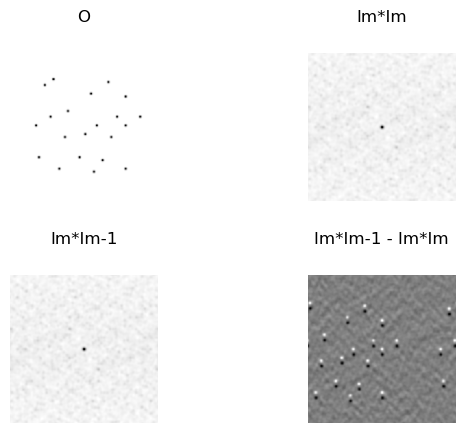

In [13]:
# Animation
#objects = backobjects.copy()

fig, ((ax1, ax2), (ax3, ax4))  = py.subplots(2,2)
ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax4.set_axis_off()
ax1.set_title("O")
ax2.set_title("Im*Im")
ax3.set_title("Im*Im-1")
ax4.set_title("Im*Im-1 - Im*Im")
#fig.color = "binary"


filenames = []
for i in range(noframes): # Repeat the following for every frame in the animation
    if i > 0: # If the current frame is not the first frame, do the following
        if i < (noframes-1):                               # Produce the object that will be used for the current frame by summing the background
            objects = backobjects.copy()                   # objects and the moving object at the position determined at the current frame
            objects += GaussPoint((xframe[i],yframe[i]),3)   
        else:                                              # If the current frame is the final frame, have it loop back to the start by considering
            objects = backobjects.copy()                   # the position of the moving object in the very first frame
            objects += GaussPoint((xframe[0],yframe[0]),3)
            
        ax1.matshow((objects), cmap="binary")

        # Find the convolution between the current state of the object and speckle pattern and subsequently the autocorrelation between the current frame and itself
        Cframeconvolution = np.fft.ifft2(np.fft.fft2(objects)*np.fft.fft2(Fspeckle))
        Cframeautocorrelation = np.fft.ifft2(np.fft.fft2(Cframeconvolution-mean)*np.conjugate(np.fft.fft2(Cframeconvolution-mean)))

        # Find the convolution between the previous state of the object and subsequently the autocorrelation between the current frame and the previous frame
        Pframeconvolution = np.fft.ifft2(np.fft.fft2(Pobjects)*np.fft.fft2(Fspeckle))
        Pframeautocorrelation = np.fft.ifft2(np.fft.fft2(Cframeconvolution-mean)*np.conjugate(np.fft.fft2(Pframeconvolution-mean)))

        # Find the difference between the autocorrelations of the current frame and previous frame, and the current frame with itself respectively
        Delautocorrelation = Pframeautocorrelation - Cframeautocorrelation

        # Shift the three autocorrelations so that the focus is in the centre
        
        Cframeautocorrelation = shift(Cframeautocorrelation)
        ax2.matshow((np.real(Cframeautocorrelation)), cmap="binary")

        Pframeautocorrelation = shift(Pframeautocorrelation)
        ax3.matshow((np.real(Pframeautocorrelation)), cmap="binary")

        Delautocorrelation = shift(Delautocorrelation)
        ax4.matshow((np.real(Delautocorrelation)), cmap="binary")

        # Save each frame as a png named after its frame number
        py.subplots_adjust(wspace=0.5, hspace=0.5)
        py.savefig("Frame" + str(i) + ".png", format="png")
        filenames.append(image.imread("Frame" + str(i) + ".png"))
        Pobjects = objects.copy()
        print("Frame" + str(i))
        
    else: # If this is the first frame, only record the position of the objects, as there is no previous frame to autocorrelate with
        objects = backobjects.copy()
        objects += GaussPoint((xframe[0],yframe[0]),3)
        Pobjects = objects.copy()
            
image.imwrite("MovingFinalCurveNonAbs.gif", filenames, duration=50, loop=0)
#py.matshow(objects, fignum=None, cmap="binary") # Plot objects

#py.savefig("Object_2dot.pdf", format="pdf")